In [6]:
# --------------------------------------------------------------
# 1. Load libraries
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [7]:
# --------------------------------------------------------------
# 2. Load the .npz file (all splits are inside)
# --------------------------------------------------------------
data = np.load('bloodmnist.npz', allow_pickle=True)

# MedMNIST v2 menyimpan data dalam bentuk:
#   train_images, train_layout
#   val_images,   val_labels
#   test_images,  test_labels
train_img = data['train_images']
train_lbl = data['train_labels'].ravel()
val_img   = data['val_images']
val_lbl   = data['val_labels'].ravel()
test_img  = data['test_images']
test_lbl  = data['test_labels'].ravel()

In [8]:
# --------------------------------------------------------------
# 3. Gabungkan SEMUA gambar & label menjadi satu dataset
# --------------------------------------------------------------
all_images = np.concatenate([train_img, val_img, test_img], axis=0)
all_labels = np.concatenate([train_lbl, val_lbl, test_lbl], axis=0)

print(f"Total samples : {all_images.shape[0]}")
print(f"Image shape   : {all_images.shape[1:]}")   # (28, 28, 3) untuk BloodMNIST (RGB)

Total samples : 17092
Image shape   : (28, 28, 3)



=== CLASS DISTRIBUTION (ALL DATA) ===
Class 0 (basophil): 1218 samples (0.0713 |  7.13%)
Class 1 (eosinophil): 3117 samples (0.1824 | 18.24%)
Class 2 (erythroblast): 1551 samples (0.0907 |  9.07%)
Class 3 (immature granulocytes): 2895 samples (0.1694 | 16.94%)
Class 4 (lymphocyte): 1214 samples (0.0710 |  7.10%)
Class 5 (monocyte): 1420 samples (0.0831 |  8.31%)
Class 6 (neutrophil): 3329 samples (0.1948 | 19.48%)
Class 7 (platelet): 2348 samples (0.1374 | 13.74%)


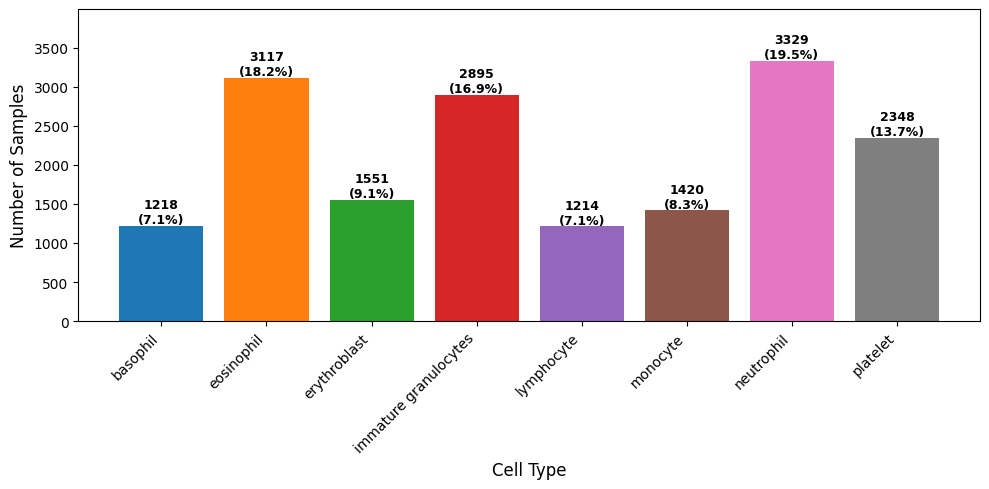

In [9]:
# --------------------------------------------------------------
# 4. Distribusi kelas & proporsi
# --------------------------------------------------------------
label_names = ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes',
               'lymphocyte', 'monocyte', 'neutrophil', 'platelet']  # 8 kelas BloodMNIST
class_counts = Counter(all_labels)
total = len(all_labels)

print("\n=== CLASS DISTRIBUTION (ALL DATA) ===")
for lbl, cnt in sorted(class_counts.items()):
    prop = cnt / total
    print(f"Class {lbl} ({label_names[lbl]}): {cnt:4d} samples "
          f"({prop:.4f} | {prop*100:5.2f}%)")

# Visualisasi distribusi
plt.figure(figsize=(10, 5))
bars = plt.bar(label_names,
               [class_counts[i] for i in range(len(label_names))],
               color=plt.cm.tab10(np.arange(len(label_names))))
plt.ylabel('Number of Samples', fontsize=12)
plt.xlabel('Cell Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + max(class_counts.values())*0.01,
             f'{int(yval)}\n({yval/total*100:.1f}%)',
             ha='center', fontsize=9, fontweight='bold')
plt.ylim(0, max(class_counts.values())*1.2)
plt.tight_layout()
plt.show()

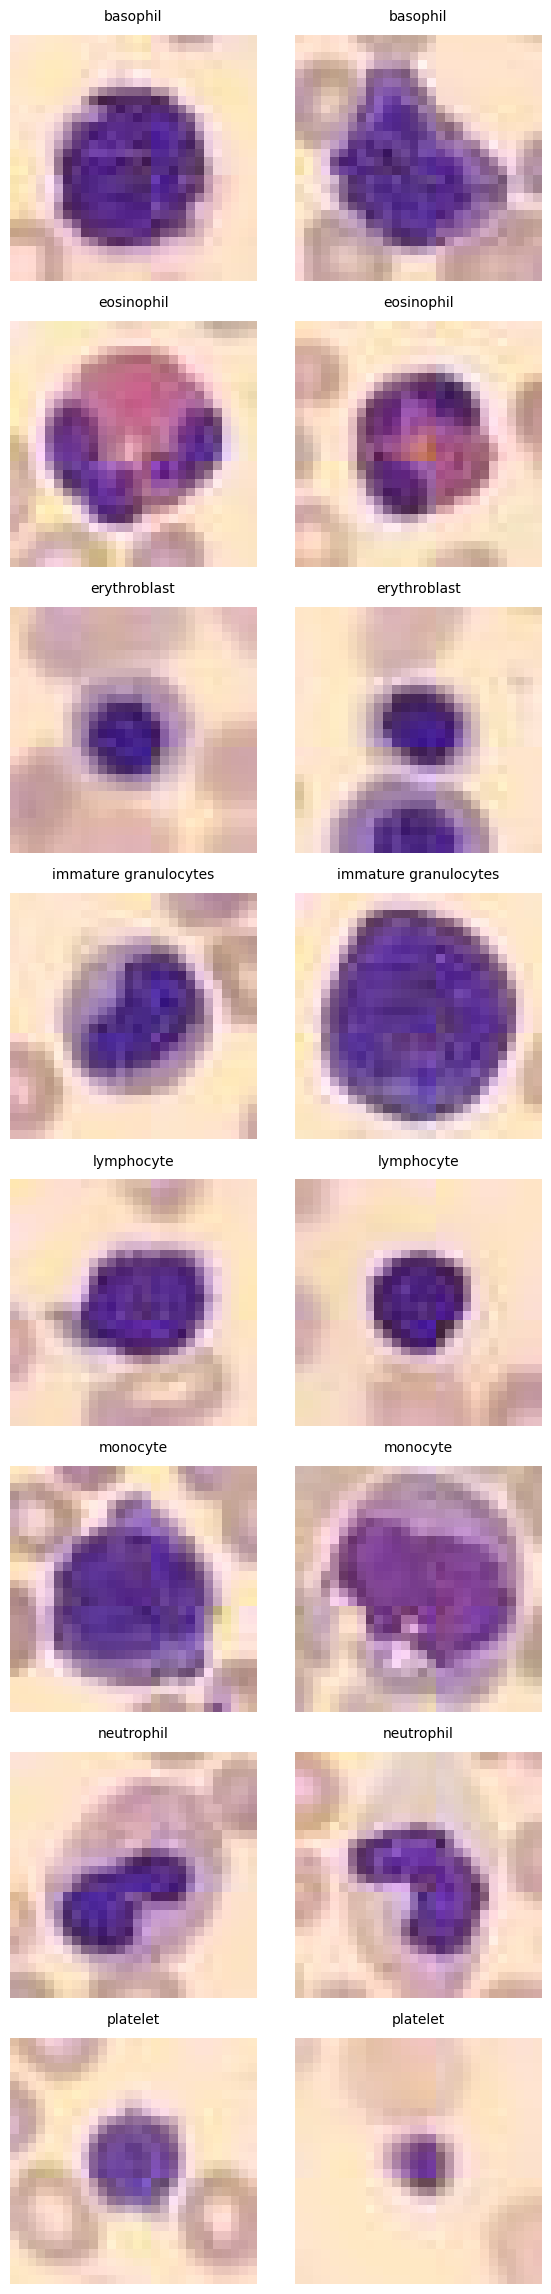

In [10]:
# --------------------------------------------------------------
# 5. Tampilkan 2 contoh gambar per kelas
# --------------------------------------------------------------
unique_classes = np.unique(all_labels)      # [0, 1, 2, ..., 7]
n_samples_per_class = 2

fig, axes = plt.subplots(nrows=len(unique_classes),
                         ncols=n_samples_per_class,
                         figsize=(3*n_samples_per_class, 3*len(unique_classes)))

for row, cls in enumerate(unique_classes):
    # Ambil indeks acak dari kelas tersebut
    idx_class = np.where(all_labels == cls)[0]
    np.random.seed(42)                     # reproducibility
    chosen = np.random.choice(idx_class, n_samples_per_class, replace=False)

    for col in range(n_samples_per_class):
        ax = axes[row, col]
        ax.imshow(all_images[chosen[col]])  # BloodMNIST: RGB, no cmap needed
        ax.set_title(f'{label_names[cls]}', fontsize=10, pad=10)
        ax.axis('off')

# plt.suptitle('Sample Images per Class – BloodMNIST (All Data)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [11]:
# --------------------------------------------------------------
# 6. Bagi dataset menjadi 3 CLIENT HETEROGEN (Dirichlet + LogNormal Size)
#    → DIPERKERAT: MINIMUM SAMPEL PER KELAS PER CLIENT
# --------------------------------------------------------------
import scipy.stats as stats
import numpy as np
from collections import Counter

np.random.seed(42)

# === MINIMUM SAMPEL PER KELAS PER CLIENT ===
min_per_class = [40, 30, 50]  # [client_1, client_2, client_3]
n_classes = 8
min_total = sum(min_per_class) * n_classes

# Pastikan dataset cukup besar
assert len(all_images) >= min_total, f"Dataset terlalu kecil! Butuh minimal {min_total} sampel."

# === Ukuran client via lognormal (setelah minimum) ===
mu_size, sigma_size = 7.0, 0.5
client_sizes_raw = np.random.lognormal(mu_size, sigma_size, 3)
client_sizes_prop = client_sizes_raw / client_sizes_raw.sum()
remaining_size = len(all_images) - min_total
client_sizes = np.round(client_sizes_prop * remaining_size).astype(int)

# Tambahkan minimum
client_sizes = np.array([client_sizes[i] + min_per_class[i] * n_classes for i in range(3)])

# Koreksi total (jika over/under)
diff = len(all_images) - client_sizes.sum()
if diff > 0:
    # Tambah ke client terbesar dulu
    for _ in range(diff):
        client_sizes[np.argmax(client_sizes)] += 1
elif diff < 0:
    # Kurangi dari client terkecil (tapi jangan sampai kurang dari min)
    for _ in range(abs(diff)):
        idx = np.argmax(client_sizes)
        if client_sizes[idx] > min_per_class[idx] * n_classes:
            client_sizes[idx] -= 1
        else:
            break  # hentikan jika sudah di batas minimum

# === Pastikan setiap kelas tersedia di semua client ===
class_indices = [np.where(all_labels == c)[0] for c in range(n_classes)]
for idx in class_indices:
    np.random.shuffle(idx)

# Pre-alokasi minimum per kelas per client
client_indices = [[] for _ in range(3)]
pointers = [0] * n_classes

# Langkah 1: Alokasi minimum
for i in range(3):
    for c in range(n_classes):
        n_take = min_per_class[i]
        if pointers[c] + n_take <= len(class_indices[c]):
            take = class_indices[c][pointers[c]:pointers[c] + n_take]
            client_indices[i].extend(take)
            pointers[c] += n_take
        else:
            # Jika tidak cukup, ambil semua sisa
            take = class_indices[c][pointers[c]:]
            client_indices[i].extend(take)
            pointers[c] = len(class_indices[c])

# Langkah 2: Hitung sisa yang harus dialokasikan
remaining_per_client = [client_sizes[i] - len(client_indices[i]) for i in range(3)]
total_remaining = sum(remaining_per_client)

# Sisa data per kelas
remaining_class = [class_indices[c][pointers[c]:] for c in range(n_classes)]
remaining_counts = np.array([len(remaining_class[c]) for c in range(n_classes)])

# === Dirichlet untuk sisa data (non-IID kuat) ===
alpha_dirichlet = 0.3
raw_props = np.random.dirichlet([alpha_dirichlet] * n_classes, size=3)  # (3, 8)
raw_props = np.clip(raw_props, 0.01, 0.99)
raw_props = raw_props / raw_props.sum(axis=0)

# Target sisa per kelas per client
target_remaining = np.zeros((3, n_classes), dtype=int)
for i in range(3):
    for c in range(n_classes):
        target_remaining[i, c] = int(raw_props[i, c] * remaining_per_client[i])
    # Koreksi total
    current = target_remaining[i].sum()
    diff = remaining_per_client[i] - current
    if diff != 0:
        idxs = np.argsort(raw_props[i])[-abs(diff):] if diff > 0 else np.argsort(-target_remaining[i])[:diff]
        for idx in idxs:
            if diff > 0:
                target_remaining[i, idx] += 1
                diff -= 1
            else:
                if target_remaining[i, idx] > 0:
                    target_remaining[i, idx] -= 1
                    diff += 1
            if diff == 0: break

# === Alokasi sisa berdasarkan target Dirichlet ===
pointers = [0] * n_classes
for i in range(3):
    for c in range(n_classes):
        n_need = target_remaining[i, c]
        if n_need > 0 and pointers[c] < len(remaining_class[c]):
            n_take = min(n_need, len(remaining_class[c]) - pointers[c])
            take = remaining_class[c][pointers[c]:pointers[c] + n_take]
            client_indices[i].extend(take)
            pointers[c] += n_take

# === Sisa akhir: distribusi merata ===
final_remaining = []
for c in range(n_classes):
    final_remaining.extend(remaining_class[c][pointers[c]:])

np.random.shuffle(final_remaining)
ptr = 0
for i in range(3):
    n_add = remaining_per_client[i] - (len(client_indices[i]) - min_per_class[i] * n_classes)
    if n_add > 0:
        add = final_remaining[ptr:ptr + n_add]
        client_indices[i].extend(add)
        ptr += n_add

# Konversi ke array
client_indices = [np.array(idx) for idx in client_indices]

# Simpan ke client_1, client_2, client_3
client_1 = {'images': all_images[client_indices[0]], 'labels': all_labels[client_indices[0]]}
client_2 = {'images': all_images[client_indices[1]], 'labels': all_labels[client_indices[1]]}
client_3 = {'images': all_images[client_indices[2]], 'labels': all_labels[client_indices[2]]}

In [12]:
# --------------------------------------------------------------
# 7. Tampilkan distribusi per client (DENGAN VERIFIKASI MINIMUM)
# --------------------------------------------------------------
label_names = ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes',
               'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

print("\n" + "="*90)
print("3 CLIENT HETEROGEN (Dirichlet α=0.3 + LogNormal Size + MINIMUM PER KELAS DIPERKERAT)")
print("="*90)

clients = [client_1, client_2, client_3]
min_req = min_per_class

for i, client in enumerate(clients, 1):
    labels = client['labels']
    total = len(labels)
    counts = Counter(labels)
    print(f"\nclient_{i} | Total={total:5d} samples")
    for c in range(n_classes):
        cnt = counts.get(c, 0)
        prop = cnt / total
        status = "OK" if cnt >= min_req[i-1] else "GAGAL"
        print(f"  → {label_names[c]:20s}: {cnt:4d} ({prop:.3f})")
    
    # Verifikasi: semua kelas ada dan memenuhi minimum
    assert all(counts.get(c, 0) >= min_req[i-1] for c in range(n_classes)), \
        f"client_{i} GAGAL memenuhi minimum {min_req[i-1]} per kelas!"


3 CLIENT HETEROGEN (Dirichlet α=0.3 + LogNormal Size + MINIMUM PER KELAS DIPERKERAT)

client_1 | Total= 8289 samples
  → basophil            :  353 (0.043)
  → eosinophil          :  141 (0.017)
  → erythroblast        :  863 (0.104)
  → immature granulocytes:  339 (0.041)
  → lymphocyte          : 1134 (0.137)
  → monocyte            :  821 (0.099)
  → neutrophil          : 2370 (0.286)
  → platelet            : 2268 (0.274)

client_2 | Total= 5187 samples
  → basophil            :  258 (0.050)
  → eosinophil          : 2926 (0.564)
  → erythroblast        :  638 (0.123)
  → immature granulocytes:  362 (0.070)
  → lymphocyte          :   30 (0.006)
  → monocyte            :  549 (0.106)
  → neutrophil          :  394 (0.076)
  → platelet            :   30 (0.006)

client_3 | Total= 3616 samples
  → basophil            :  607 (0.168)
  → eosinophil          :   50 (0.014)
  → erythroblast        :   50 (0.014)
  → immature granulocytes: 2194 (0.607)
  → lymphocyte          :   50 (0.0

In [13]:
# --------------------------------------------------------------
# 8. Uji Statistik: Chi-Square untuk Heterogenitas Label
# --------------------------------------------------------------
print("\n" + "-"*80)
print("UJI CHI-SQUARE: Homogeneity of Class Distributions (8 Classes)")
print("-"*80)

contingency = np.array([
    [np.sum(c['labels'] == cls) for cls in range(n_classes)] for c in clients
])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:.2f}")
print(f"p-value              : {p_chi2:.2e}")
print(f"Degrees of freedom   : {dof}")
print(f"Reject H0 (p < 0.05) : {'YES' if p_chi2 < 0.05 else 'NO'}")
print("→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN." if p_chi2 < 0.05 else "→ Tidak cukup bukti.")


--------------------------------------------------------------------------------
UJI CHI-SQUARE: Homogeneity of Class Distributions (8 Classes)
--------------------------------------------------------------------------------
Chi-square statistic : 16242.23
p-value              : 0.00e+00
Degrees of freedom   : 14
Reject H0 (p < 0.05) : YES
→ Distribusi kelas antar client BERBEDA SECARA SIGNIFIKAN.


In [14]:
# --------------------------------------------------------------
# 9. Uji KS pada Mean Pixel Intensity (RGB → Mean across channels)
# --------------------------------------------------------------
print("\n" + "-"*80)
print("UJI KOLMOGOROV-SMIRNOV: Distribusi Intensitas Rata-rata (RGB → Mean per Image)")
print("-"*80)

mean_intensities = [np.mean(c['images'], axis=(1,2,3)) for c in clients]
sig_count = 0
total_pairs = 0
for i in range(3):
    for j in range(i+1, 3):
        total_pairs += 1
        ks_stat, p_ks = stats.ks_2samp(mean_intensities[i], mean_intensities[j])
        if p_ks < 0.05:
            sig_count += 1
            print(f"client_{i+1} vs client_{j+1}: p = {p_ks:.2e} → BERBEDA")

print(f"\nPasangan signifikan (p<0.05): {sig_count}/{total_pairs}")


--------------------------------------------------------------------------------
UJI KOLMOGOROV-SMIRNOV: Distribusi Intensitas Rata-rata (RGB → Mean per Image)
--------------------------------------------------------------------------------
client_1 vs client_2: p = 1.15e-320 → BERBEDA
client_1 vs client_3: p = 9.01e-321 → BERBEDA
client_2 vs client_3: p = 2.35e-31 → BERBEDA

Pasangan signifikan (p<0.05): 3/3


In [15]:
# --------------------------------------------------------------
# 10. FULL FEDERATED LEARNING PIPELINE 
# --------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, precision_recall_curve, roc_curve, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

# Seed
torch.manual_seed(42)
np.random.seed(42)

In [16]:
# --------------------------------------------------------------
# 10.1 CNN Ringan (Multiclass + RGB)
# --------------------------------------------------------------
class LightweightCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)   # Input: 3 channel (RGB)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, num_classes)        # 8 kelas
        self.dropout = nn.Dropout(0.25)
   
    def forward(self, x):
        # x: (B, 28, 28, 3) → ubah ke (B, 3, 28, 28)
        if x.dim() == 4 and x.shape[-1] == 3:
            x = x.permute(0, 3, 1, 2)
        x = x.float() / 255.0
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.reshape(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Model
model = LightweightCNN(num_classes=8)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

LightweightCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=8, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Total parameters: 106,024


In [17]:
# --------------------------------------------------------------
# 10.2 Evaluation & Metrics (Multiclass)
# --------------------------------------------------------------
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            # Pastikan format NCHW
            if Xb.dim() == 4 and Xb.shape[-1] == 3:
                Xb = Xb.permute(0, 3, 1, 2)
            out = model(Xb)
            prob = F.softmax(out, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)
            y_true.extend(yb.cpu().numpy().flatten())
            y_pred.extend(pred)
            y_prob.extend(prob)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        y_true_onehot = np.eye(8)[y_true]
        auc = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
    except:
        auc = 0.5
    try:
        logloss = log_loss(y_true, y_prob, labels=list(range(8)))
    except:
        logloss = 2.079
    return {
        'akurasi': acc, 'presisi': prec, 'recall': rec,
        'f1_score': f1, 'roc_auc': auc, 'log_loss': logloss
    }

def train_local(model, loader, epochs=1, lr=0.01):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for Xb, yb in loader:
            # Pastikan format NCHW
            if Xb.dim() == 4 and Xb.shape[-1] == 3:
                Xb = Xb.permute(0, 3, 1, 2)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb.long())
            loss.backward()
            optimizer.step()
    return model

In [18]:
# --------------------------------------------------------------
# 10.3 5-Fold CV + 4 Global Models
# --------------------------------------------------------------
clients = [client_1, client_2, client_3]
K = len(clients)
fold_results = {name: [] for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']}
all_y_true = {name: [] for name in fold_results}
all_y_prob = {name: [] for name in fold_results}

for fold in range(5):
    print(f"\n{'='*70}")
    print(f"{' '*25} FOLD {fold+1}/5")
    print(f"{'='*70}")
   
    # Split per client
    train_loaders, test_loaders, client_sizes = [], [], []
    for client in clients:
        X, y = client['images'], client['labels']
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + fold)
        for train_idx, test_idx in skf.split(X, y):
            X_train = torch.tensor(X[train_idx])
            y_train = torch.tensor(y[train_idx])
            X_test = torch.tensor(X[test_idx])
            y_test = torch.tensor(y[test_idx])
            train_loaders.append(DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True))
            test_loaders.append(DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False))
            client_sizes.append(len(train_idx))
            break
    total_n = sum(client_sizes)
   
    # Global models
    global_models = {name: copy.deepcopy(model) for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']}
   
    # Control variates
    params = list(model.parameters())
    c_global = {name: [torch.zeros_like(p) for p in params] for name in ['fedsvrg']}
    c_local = [[torch.zeros_like(p) for p in params] for _ in range(K)]
   
    round_metrics = {name: [] for name in fold_results}
   
    for round_num in range(1, 51):
        # Local training
        local_models = [train_local(copy.deepcopy(model), loader, epochs=1) for loader in train_loaders]
        local_params = [list(m.parameters()) for m in local_models]
       
        # LOCAL EVAL
        local_scores = []
        for i, loader in enumerate(test_loaders):
            yt, yp, ypr = evaluate_model(local_models[i], loader)
            local_scores.append(compute_metrics(yt, yp, ypr))
        local_avg = {k: np.mean([m[k] for m in local_scores]) for k in local_scores[0]}
        round_metrics['local'].append(local_avg)
       
        # 1. FedAvg
        w_avg = copy.deepcopy(global_models['fedavg'])
        for p in w_avg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_avg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedavg'] = w_avg
       
        # 2. FedProx
        w_prox = copy.deepcopy(global_models['fedprox'])
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_prox)
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.CrossEntropyLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    if Xb.dim() == 4 and Xb.shape[-1] == 3:
                        Xb = Xb.permute(0, 3, 1, 2)
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb.long())
                    prox = 0.01/2 * sum((p-q).norm(2)**2 for p, q in zip(m.parameters(), w_prox.parameters()))
                    (loss + prox).backward()
                    opt.step()
            local_models[i] = m
        for p in w_prox.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = client_sizes[i] / total_n
            for pg, pl in zip(w_prox.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedprox'] = w_prox
       
        # 3. FedSVRG (SCAFFOLD)
        w_svrg = copy.deepcopy(global_models['fedsvrg'])
        w_params = list(w_svrg.parameters())
        for i, loader in enumerate(train_loaders):
            m = copy.deepcopy(w_svrg)
            m_params = list(m.parameters())
            opt = optim.Adam(m.parameters(), lr=0.01)
            crit = nn.CrossEntropyLoss()
            for _ in range(3):
                for Xb, yb in loader:
                    if Xb.dim() == 4 and Xb.shape[-1] == 3:
                        Xb = Xb.permute(0, 3, 1, 2)
                    opt.zero_grad()
                    out = m(Xb)
                    loss = crit(out, yb.long())
                    loss.backward()
                    for j, (p, c_k, c_g) in enumerate(zip(m_params, c_local[i], c_global['fedsvrg'])):
                        if p.grad is not None:
                            p.grad = p.grad - c_k + c_g
                    opt.step()
            local_models[i] = m
            local_params[i] = m_params
       
        # Update control variates
        for j in range(len(w_params)):
            delta = sum((local_params[i][j] - w_params[j]) for i in range(K)) / K
            c_global['fedsvrg'][j] += delta
            for i in range(K):
                c_local[i][j] = c_global['fedsvrg'][j]
       
        # Aggregation
        for p in w_svrg.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            w = 1.0 / K
            for pg, pl in zip(w_svrg.parameters(), m.parameters()):
                pg.data += w * pl.data
        global_models['fedsvrg'] = w_svrg
       
        # 4. FedAtt
        w_att = copy.deepcopy(global_models['fedatt'])
        sims = []
        for m in local_models:
            sim = sum(F.cosine_similarity(pg.flatten(), pl.flatten(), dim=0)
                      for pg, pl in zip(w_att.parameters(), m.parameters()))
            sims.append(sim.item())
        attn = F.softmax(torch.tensor(sims), dim=0)
        for p in w_att.parameters(): p.data.zero_()
        for i, m in enumerate(local_models):
            for pg, pl in zip(w_att.parameters(), m.parameters()):
                pg.data += attn[i] * pl.data
        global_models['fedatt'] = w_att
       
        # GLOBAL EVAL
        for name in ['fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            gmodel = global_models[name]
            scores = []
            y_true_all, y_prob_all = [], []
            for loader in test_loaders:
                yt, yp, ypr = evaluate_model(gmodel, loader)
                scores.append(compute_metrics(yt, yp, ypr))
                y_true_all.extend(yt)
                y_prob_all.extend(ypr)
            avg = {k: np.mean([m[k] for m in scores]) for k in scores[0]}
            round_metrics[name].append(avg)
            if round_num == 50:
                all_y_true[name].append(np.array(y_true_all))
                all_y_prob[name].append(np.array(y_prob_all))
       
        # Save local for curves
        if round_num == 50:
            yt_all, ypr_all = [], []
            for i, loader in enumerate(test_loaders):
                yt, yp, ypr = evaluate_model(local_models[i], loader)
                yt_all.extend(yt); ypr_all.extend(ypr)
            all_y_true['local'].append(np.array(yt_all))
            all_y_prob['local'].append(np.array(ypr_all))
       
        # PRINT
        print(f"\n--- Round {round_num} ---")
        for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
            m = round_metrics[name][-1]
            print(f"{name.upper()} round {round_num}")
            print(f" akurasi : {m['akurasi']:.4f}")
            print(f" presisi : {m['presisi']:.4f}")
            print(f" recall : {m['recall']:.4f}")
            print(f" f1_score: {m['f1_score']:.4f}")
            print(f" roc_auc : {m['roc_auc']:.4f}")
            print(f" log_loss: {m['log_loss']:.4f}")
   
    for name in round_metrics:
        fold_results[name].append(round_metrics[name])


                          FOLD 1/5

--- Round 1 ---
LOCAL round 1
 akurasi : 0.6949
 presisi : 0.2700
 recall : 0.2926
 f1_score: 0.2737
 roc_auc : 0.7606
 log_loss: 0.9642
FEDAVG round 1
 akurasi : 0.2553
 presisi : 0.1264
 recall : 0.2245
 f1_score: 0.1384
 roc_auc : 0.7687
 log_loss: 1.9609
FEDPROX round 1
 akurasi : 0.3657
 presisi : 0.2602
 recall : 0.3915
 f1_score: 0.2661
 roc_auc : 0.8777
 log_loss: 1.7022
FEDSVRG round 1
 akurasi : 0.2098
 presisi : 0.0710
 recall : 0.1886
 f1_score: 0.0858
 roc_auc : 0.8557
 log_loss: 1.8756
FEDATT round 1
 akurasi : 0.3902
 presisi : 0.0929
 recall : 0.2380
 f1_score: 0.1204
 roc_auc : 0.8809
 log_loss: 1.6714

--- Round 2 ---
LOCAL round 2
 akurasi : 0.7024
 presisi : 0.2705
 recall : 0.3083
 f1_score: 0.2805
 roc_auc : 0.7745
 log_loss: 0.9477
FEDAVG round 2
 akurasi : 0.1727
 presisi : 0.0216
 recall : 0.1250
 f1_score: 0.0357
 roc_auc : 0.8245
 log_loss: 1.9158
FEDPROX round 2
 akurasi : 0.5835
 presisi : 0.5775
 recall : 0.6531
 f1_sco


                          AVERAGE OF 5 FOLDS

--- Round 1 ---
LOCAL round 1
  Accuracy : 0.6853
  Precision: 0.2653
  Recall   : 0.2862
  F1-Score : 0.2638
  ROC-AUC  : 0.7564
  Log-Loss : 0.9850
FEDAVG round 1
  Accuracy : 0.1816
  Precision: 0.0530
  Recall   : 0.1568
  F1-Score : 0.0640
  ROC-AUC  : 0.7690
  Log-Loss : 2.0899
FEDPROX round 1
  Accuracy : 0.3079
  Precision: 0.1921
  Recall   : 0.3200
  F1-Score : 0.1944
  ROC-AUC  : 0.8535
  Log-Loss : 1.8511
FEDSVRG round 1
  Accuracy : 0.1965
  Precision: 0.0646
  Recall   : 0.1808
  F1-Score : 0.0771
  ROC-AUC  : 0.7544
  Log-Loss : 1.9529
FEDATT round 1
  Accuracy : 0.2756
  Precision: 0.0543
  Recall   : 0.1643
  F1-Score : 0.0679
  ROC-AUC  : 0.7488
  Log-Loss : 1.8887

--- Round 2 ---
LOCAL round 2
  Accuracy : 0.6737
  Precision: 0.2741
  Recall   : 0.2790
  F1-Score : 0.2567
  ROC-AUC  : 0.7526
  Log-Loss : 1.0092
FEDAVG round 2
  Accuracy : 0.1677
  Precision: 0.0553
  Recall   : 0.1414
  F1-Score : 0.0469
  ROC-AUC  : 0.

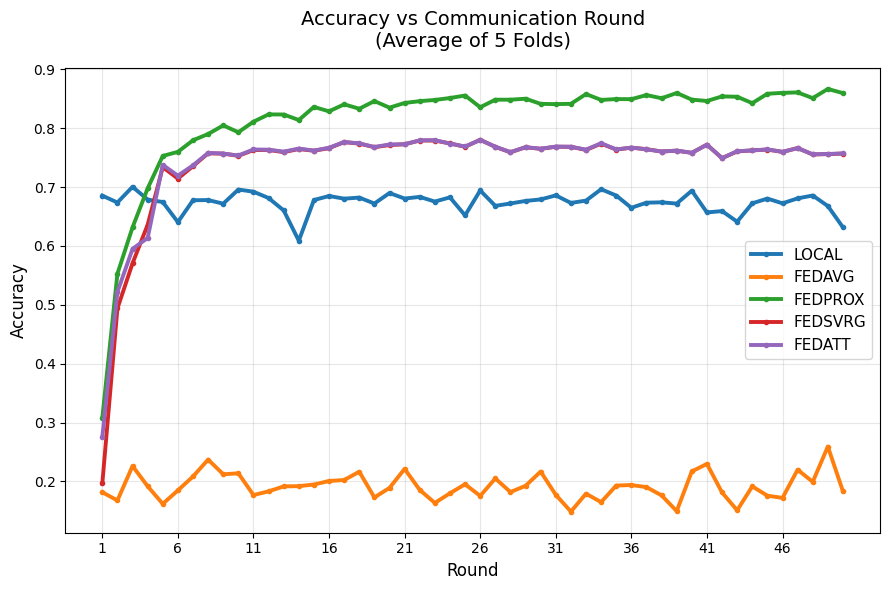

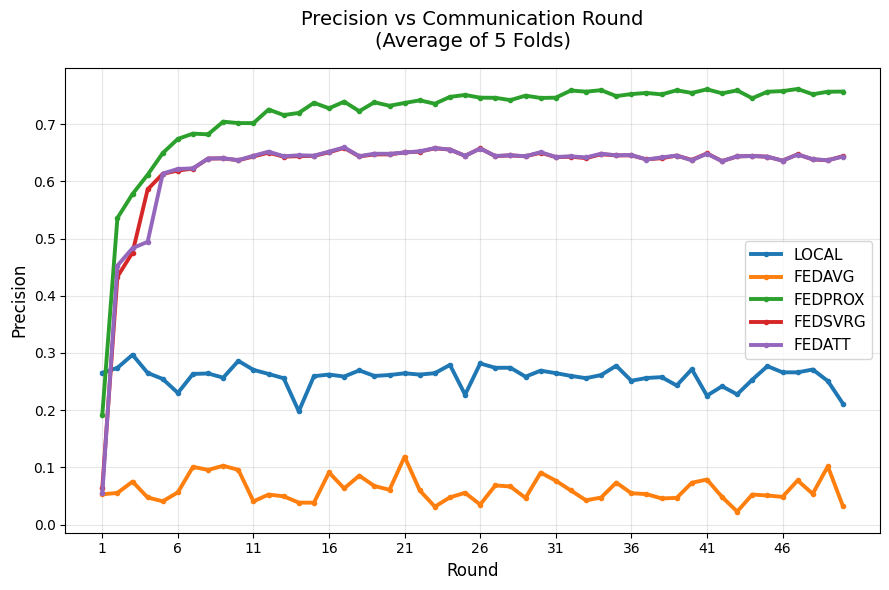

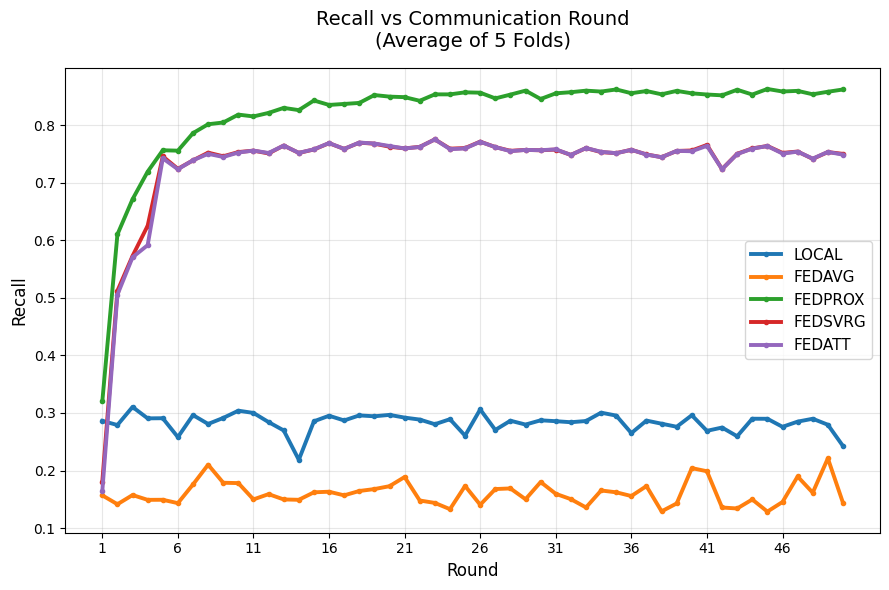

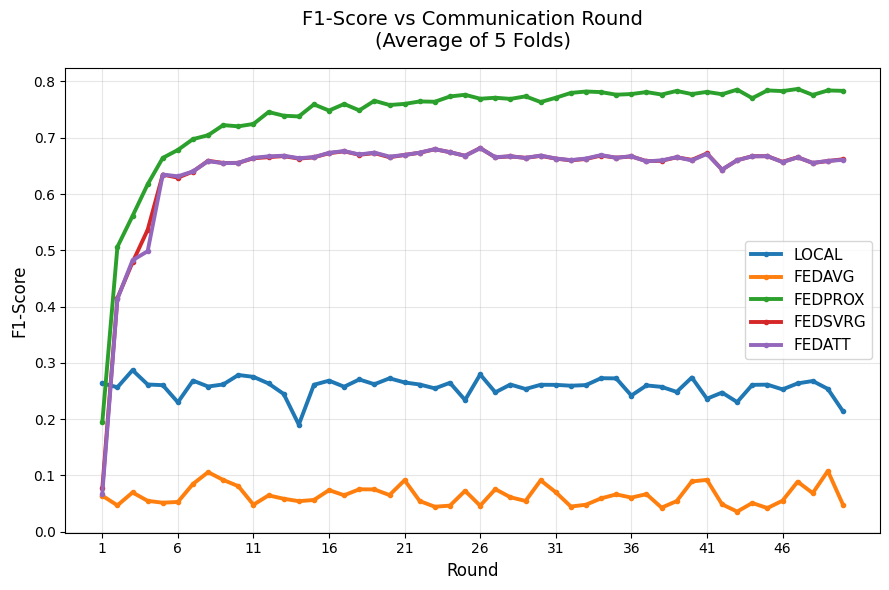

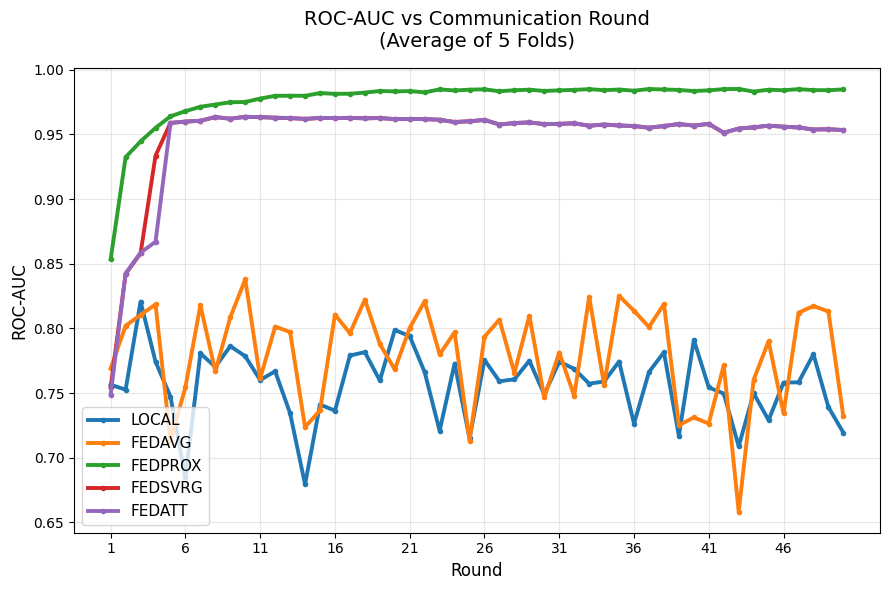

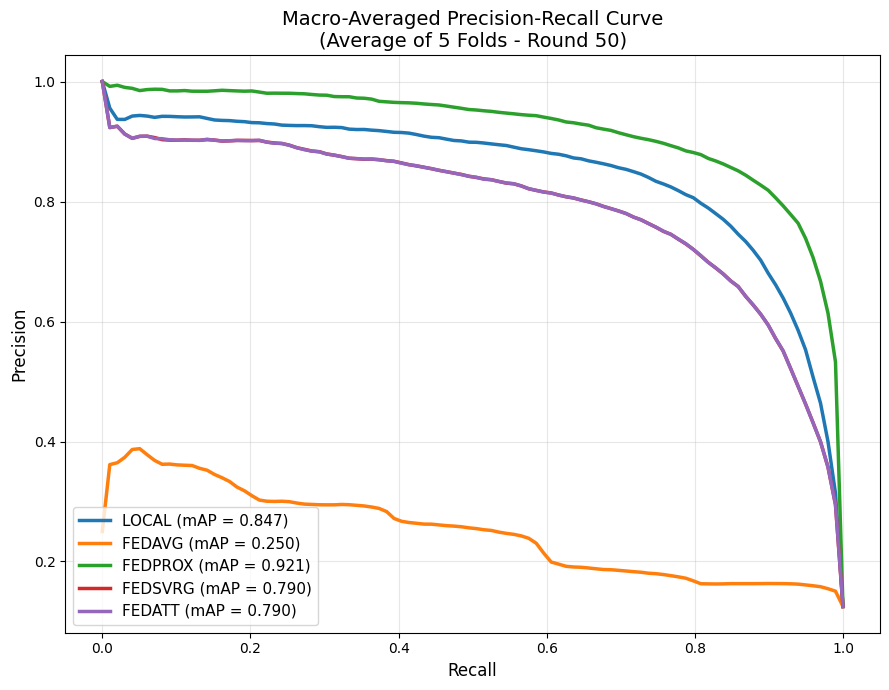

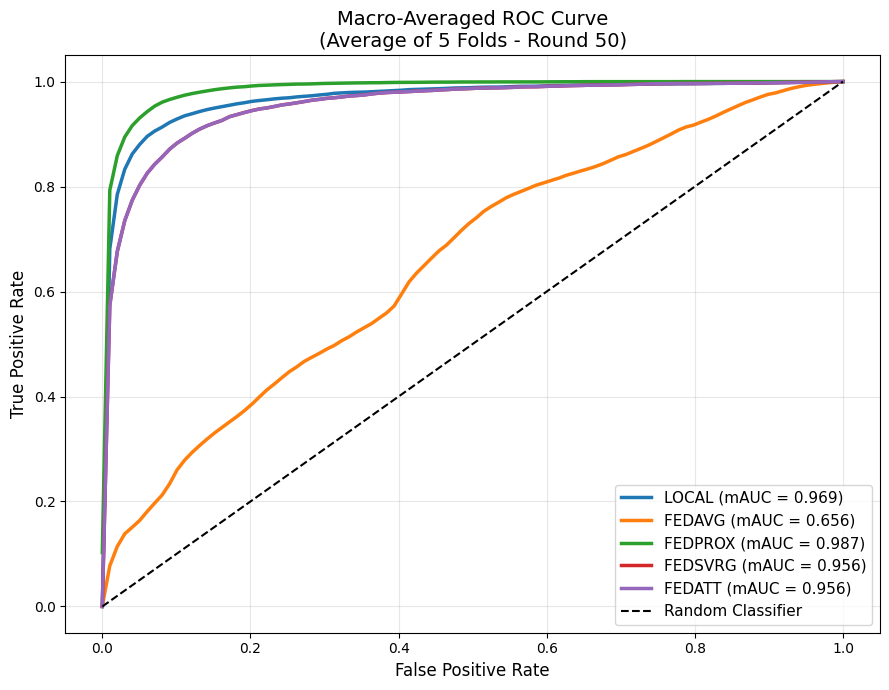

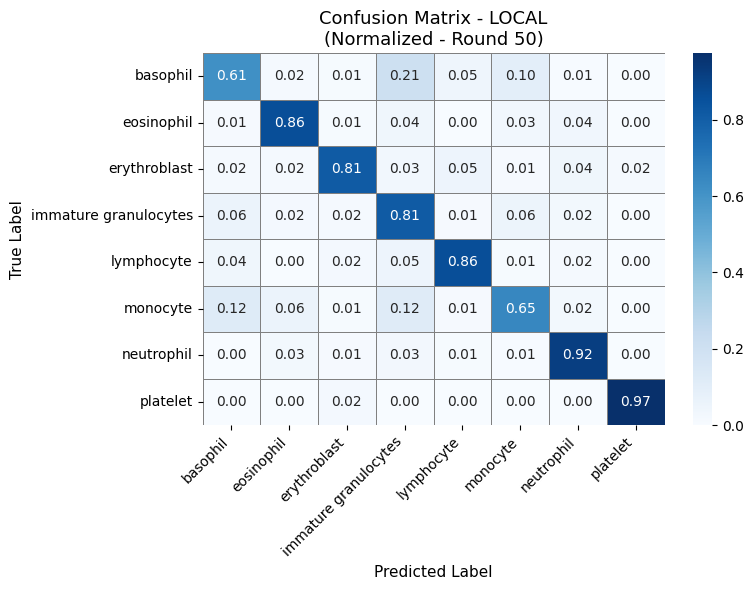

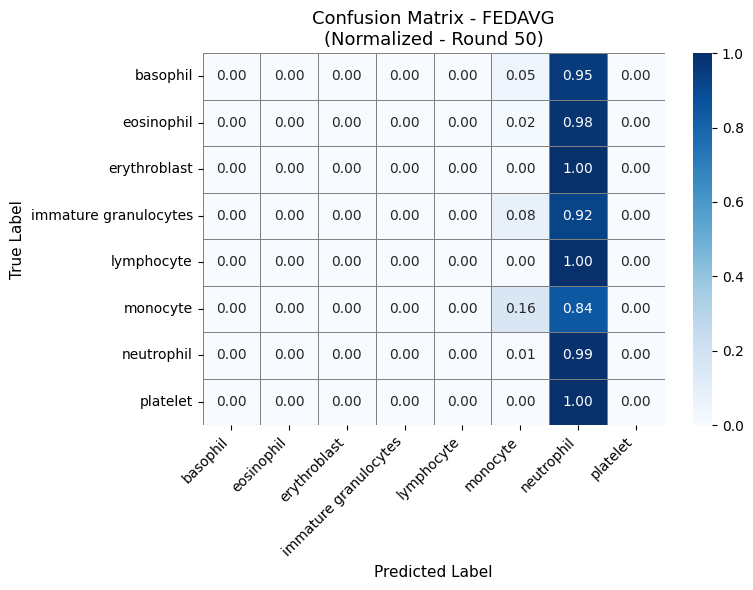

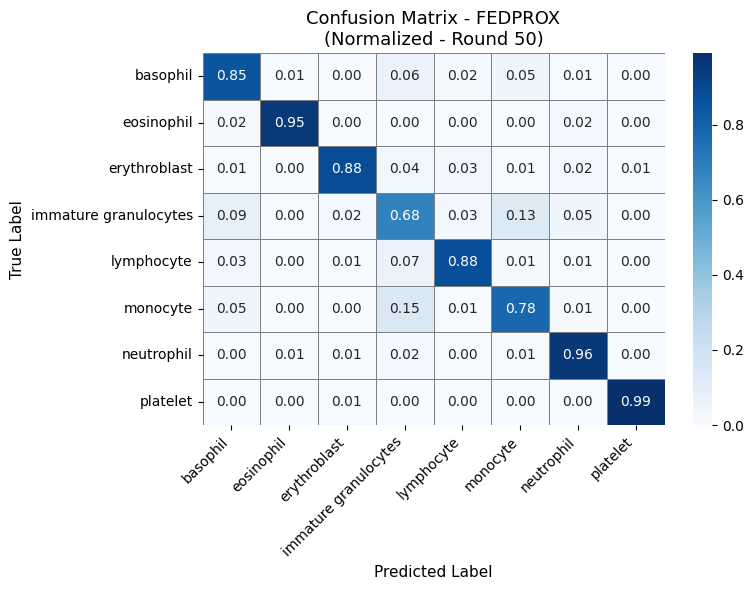

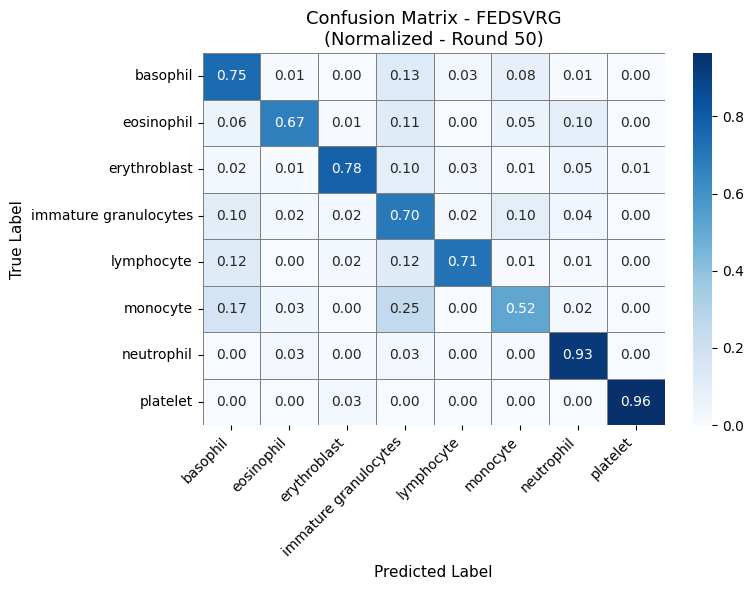

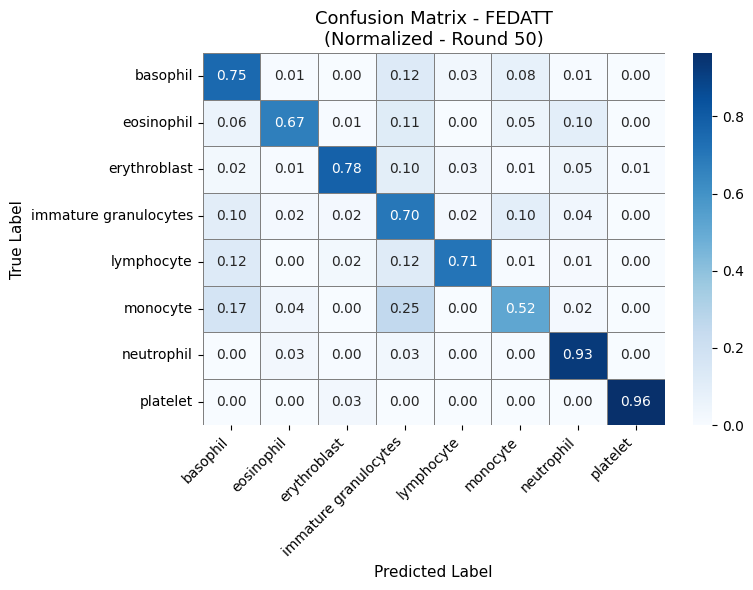


FINAL PERFORMANCE (Round 50 - Average of 5 Folds)
Model         Accuracy  Precision   Recall       F1      AUC     Loss
----------------------------------------------------------------------------------------------------
LOCAL        0.6315    0.2114     0.2426   0.2140   0.7194   1.0999
FEDAVG       0.1831    0.0320     0.1439   0.0481   0.7319   1.9868
FEDPROX      0.8595    0.7571     0.8619   0.7834   0.9848   0.4066
FEDSVRG      0.7568    0.6441     0.7501   0.6618   0.9534   1.0513
FEDATT       0.7569    0.6434     0.7487   0.6607   0.9534   1.0509


In [19]:
# --------------------------------------------------------------
# 11. AGGREGATION OF 5 FOLDS + FINAL VISUALIZATION (REVISED)
#     - Separate figures (1 image per plot)
#     - All in English
#     - Line plots: 1 metric per figure
#     - PR Curve: Macro-averaged per class
#     - ROC Curve: Macro-averaged per class
#     - Confusion Matrix: 5 separate figures (8x8)
# --------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, confusion_matrix, average_precision_score
import seaborn as sns

# === 1. Aggregate 5 Folds ===
avg_round = {name: [] for name in fold_results}
for name in fold_results:
    for r in range(50):
        round_data = [fold_results[name][f][r] for f in range(5)]
        avg = {k: np.mean([m[k] for m in round_data]) for k in round_data[0]}
        avg_round[name].append(avg)

# === 2. PRINT AVERAGE 5 FOLDS (ENGLISH) ===
print(f"\n{'='*70}")
print(f"{' '*25} AVERAGE OF 5 FOLDS")
print(f"{'='*70}")
for round_num in range(1, 51):
    print(f"\n--- Round {round_num} ---")
    for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
        m = avg_round[name][round_num-1]
        print(f"{name.upper()} round {round_num}")
        print(f"  Accuracy : {m['akurasi']:.4f}")
        print(f"  Precision: {m['presisi']:.4f}")
        print(f"  Recall   : {m['recall']:.4f}")
        print(f"  F1-Score : {m['f1_score']:.4f}")
        print(f"  ROC-AUC  : {m['roc_auc']:.4f}")
        print(f"  Log-Loss : {m['log_loss']:.4f}")

# === 3. LINE PLOTS: 1 METRIC PER FIGURE ===
metrics = ['akurasi', 'presisi', 'recall', 'f1_score', 'roc_auc', 'log_loss']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Log-Loss']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for met, title, color in zip(metrics, titles, colors):
    plt.figure(figsize=(9, 6))
    for i, algo in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
        vals = [r[met] for r in avg_round[algo]]
        plt.plot(range(1, 51), vals, label=algo.upper(), linewidth=2.8, color=colors[i], marker='o', markersize=3)
    plt.title(f'{title} vs Communication Round\n(Average of 5 Folds)', fontsize=14, pad=15)
    plt.xlabel('Round', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 51, 5))
    plt.tight_layout()
    plt.show()

# === 4. PRECISION-RECALL CURVE (MACRO-AVERAGED PER CLASS) ===
plt.figure(figsize=(9, 7))
label_names = ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes',
               'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])  # (N, 8)
    # Macro-average PR curve
    precision, recall, _ = {}, {}, {}
    for cls in range(8):
        precision[cls], recall[cls], _ = precision_recall_curve(y_true == cls, y_prob[:, cls])
    # Average
    all_recall = np.linspace(0, 1, 100)
    mean_precision = np.zeros_like(all_recall)
    for cls in range(8):
        interp_prec = np.interp(all_recall, recall[cls][::-1], precision[cls][::-1])
        mean_precision += interp_prec
    mean_precision /= 8
    ap_macro = average_precision_score(np.eye(8)[y_true], y_prob, average='macro')
    plt.plot(all_recall, mean_precision, label=f"{name.upper()} (mAP = {ap_macro:.3f})", linewidth=2.5, color=colors[i])

plt.title('Macro-Averaged Precision-Recall Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 5. ROC CURVE (MACRO-AVERAGED PER CLASS) ===
plt.figure(figsize=(9, 7))
for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    # Macro-average ROC
    fpr, tpr = {}, {}
    for cls in range(8):
        fpr[cls], tpr[cls], _ = roc_curve(y_true == cls, y_prob[:, cls])
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    for cls in range(8):
        interp_tpr = np.interp(all_fpr, fpr[cls], tpr[cls])
        mean_tpr += interp_tpr
    mean_tpr /= 8
    auc_macro = roc_auc_score(np.eye(8)[y_true], y_prob, average='macro', multi_class='ovr')
    plt.plot(all_fpr, mean_tpr, label=f"{name.upper()} (mAUC = {auc_macro:.3f})", linewidth=2.5, color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.title('Macro-Averaged ROC Curve\n(Average of 5 Folds - Round 50)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 6. CONFUSION MATRIX: 5 SEPARATE FIGURES (8x8) ===
model_names = ['LOCAL', 'FEDAVG', 'FEDPROX', 'FEDSVRG', 'FEDATT']

for i, name in enumerate(['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']):
    y_true = np.concatenate(all_y_true[name])
    y_prob = np.concatenate(all_y_prob[name])
    y_pred = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                cbar=True, square=False, linewidths=0.5, linecolor='gray')
    plt.title(f'Confusion Matrix - {model_names[i]}\n(Normalized - Round 50)', fontsize=13)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# === 7. FINAL PERFORMANCE TABLE ===
print("\n" + "="*100)
print("FINAL PERFORMANCE (Round 50 - Average of 5 Folds)")
print("="*100)
print(f"{'Model':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Loss':>8}")
print("-"*100)
for name in ['local', 'fedavg', 'fedprox', 'fedsvrg', 'fedatt']:
    r = avg_round[name][-1]
    print(f"{name.upper():<12} {r['akurasi']:.4f}    {r['presisi']:.4f}     {r['recall']:.4f}   {r['f1_score']:.4f}   {r['roc_auc']:.4f}   {r['log_loss']:.4f}")